In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import time

import richio
import unyt as u
import dev


In [78]:
path = "/data1/projects/pi-rossiem/TDE_data/R0.47M0.5BH10000beta1S60n1.5ComptonHiResNewAMR/snap_80"

In [79]:
snap = richio.load(path)

In [80]:
X = snap.CMx
Y = snap.CMy
Z = snap.CMz
r = np.sqrt(X**2 + Y**2 + Z**2)

In [81]:
B = (
    -u.G * 1e4 * richio.units.mscale / r
    + 0.5 * (snap.vx**2 + snap.vy**2 + snap.vz**2)
    + snap.sie
    + (snap.P / snap.rho + snap.Erad / 3)
)

In [82]:
vr = (snap.vx * X + snap.vy * Y + snap.vz * Z) / r

In [83]:
# !!!
X -= 13 * richio.units.lscale
r = np.sqrt(X**2 + Y**2 + Z**2)

In [84]:
peri_wind_mask = (B > 0) & (X > 0) & (vr > 0) & (Z / r < 0.5)
stream_wind_mask = (B > 0) & (X < 0) & (vr > 0) & (Z / r < 0.5)
wind_mask = (B > 0) & (vr > 0) & (Z / r < 0.5)

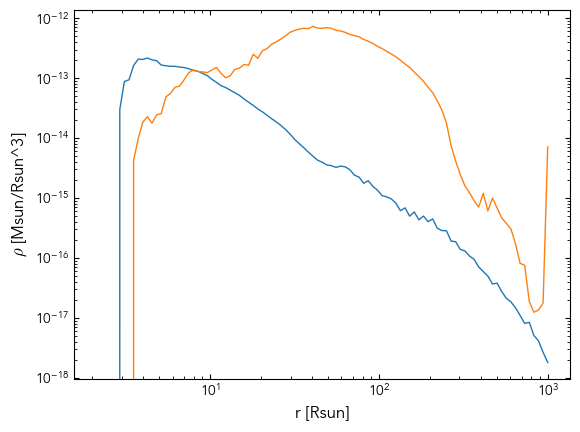

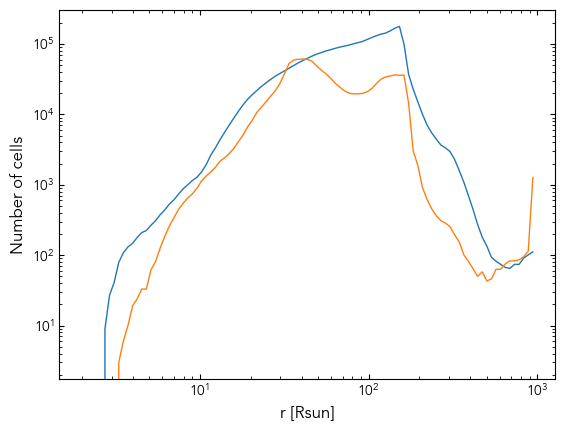

In [85]:
bins = np.logspace(np.log10(2), np.log10(1000), 100)
for mask in [peri_wind_mask, stream_wind_mask]:
    hist, bin_edges = np.histogram(
        r[mask], bins, weights=(snap.density * snap.volume)[mask]
    )
    plt.plot(
        bins[1:],
        hist / (4 * np.pi * bins[1:] ** 2 * (bins[1:] - bins[:-1])),
    )
plt.xlabel("r [Rsun]")
plt.ylabel(r"$\rho$ [Msun/Rsun^3]")
plt.xscale("log")
plt.yscale("log")
plt.show()

for mask in [peri_wind_mask, stream_wind_mask]:
    hist, bin_edges = np.histogram(r[mask], bins)
    plt.plot(
        bins[:-1],
        hist,
    )
plt.xlabel("r [Rsun]")
plt.ylabel(r"Number of cells")
plt.xscale("log")
plt.yscale("log")
plt.show()